# Project Lab Trend Model Backtest — Method 1

Trend signals (20-day vs 63-day SMA crossover):

- AUDUSD: long B1MLAUUS when 20-day MA > 63-day MA
- BCOM: long BCOM when 20-day MA > 63-day MA
- XAU: long gold when 20-day MA > 63-day MA
- USDBRL: long B1MLBRUS when 20-day MA < 63-day MA

Sizing (Method 1): start with $100M; each active signal gets 25% of AUM.

| Active signals | Total exposure |
| --- | --- |
| 0 | 0% |
| 1 | 25% |
| 2 | 50% |
| 3 | 75% |
| 4 | 100% |


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter
from pathlib import Path
from IPython.display import display

START_DATE = "2002-01-01"
INITIAL_AUM = 100_000_000
FAST_WINDOW = 20
SLOW_WINDOW = 63
WEIGHT_PER_SIGNAL = 0.25
TRADING_DAYS = 252

OUTPUT_DIR = Path("output_method1")
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_CANDIDATES = [
    Path("data/trend_model_index_prices_cleaned.xlsx"),
    Path("trend_model_index_prices_cleaned.xlsx"),
    Path("/mnt/data/trend_model_index_prices_cleaned.xlsx"),
    Path("/mnt/data/trend_model_index_prices_cleaned(2).xlsx"),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find trend_model_index_prices_cleaned.xlsx. Put it in ./data or update DATA_PATH.")

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "axes.titleweight": "bold",
    "axes.edgecolor": "#333333",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#D9D9D9",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.65,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

COLORS = {
    "BRL": "#1F4E79",
    "AUD": "#70AD47",
    "BCOM": "#C55A11",
    "XAU": "#B08D00",
    "Cash": "#BFBFBF",
    "NAV": "#1F4E79",
    "Drawdown": "#C00000",
    "Positive": "#2E7D32",
    "Negative": "#C62828",
    "Risk Assets": "#1F4E79",
}

asset_order = ["BRL", "AUD", "BCOM", "XAU"]

def pct_fmt(x, pos):
    return f"{x:.0%}"

def dollar_m_fmt(x, pos):
    return f"${x:,.0f}m"

def clean_axis(ax, percent_y=False, percent_x=False, millions_y=False):
    ax.grid(True, axis="y")
    ax.grid(False, axis="x")
    if percent_y:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    if percent_x:
        ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    if millions_y:
        ax.yaxis.set_major_formatter(FuncFormatter(dollar_m_fmt))
    return ax

def savefig(name):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / name, bbox_inches="tight")
    plt.show()

DATA_PATH


PosixPath('/mnt/data/trend_model_index_prices_cleaned(2).xlsx')

## Load data

In [2]:

df = pd.read_excel(DATA_PATH)

date_col = "Dates" if "Dates" in df.columns else df.columns[0]
df[date_col] = pd.to_datetime(df[date_col])
df = df.set_index(date_col).sort_index()
df = df.loc[START_DATE:].copy()
df = df.apply(pd.to_numeric, errors="coerce")
df = df.dropna(how="all").ffill()

signal_assets = {
    "BRL": "USDBRL Curncy",
    "AUD": "AUDUSD Curncy",
    "BCOM": "BCOM Index",
    "XAU": "XAU Curncy",
}

trade_assets = {
    "BRL": "B1MLBRUS Index",
    "AUD": "B1MLAUUS Index",
    "BCOM": "BCOM Index",
    "XAU": "XAU Curncy",
}

needed_cols = sorted(set(signal_assets.values()) | set(trade_assets.values()))
missing_cols = [c for c in needed_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

df[needed_cols].head()


,AUDUSD Curncy,B1MLAUUS Index,B1MLBRUS Index,BCOM Index,USDBRL Curncy,XAU Curncy
Dates,,,,,,
2002-01-01,0.5097,74.4530,98.3952,89.0333,2.3105,278.95
2002-01-02,0.5148,75.1285,98.7305,89.8835,2.3020,278.75
2002-01-03,0.5155,75.0998,99.2626,89.6259,2.2950,278.45
2002-01-04,0.5207,75.9644,97.6957,91.4464,2.3310,278.95
2002-01-07,0.5183,75.7220,98.0359,92.3617,2.3270,278.75


## Build trend signals

In [3]:

ma_fast = pd.DataFrame(index=df.index)
ma_slow = pd.DataFrame(index=df.index)
signals = pd.DataFrame(index=df.index)

for asset, col in signal_assets.items():
    ma_fast[asset] = df[col].rolling(FAST_WINDOW, min_periods=FAST_WINDOW).mean()
    ma_slow[asset] = df[col].rolling(SLOW_WINDOW, min_periods=SLOW_WINDOW).mean()

signals["BRL"] = ma_fast["BRL"] < ma_slow["BRL"]
signals["AUD"] = ma_fast["AUD"] > ma_slow["AUD"]
signals["BCOM"] = ma_fast["BCOM"] > ma_slow["BCOM"]
signals["XAU"] = ma_fast["XAU"] > ma_slow["XAU"]

signals = signals.astype(float)
positions = signals.shift(1).fillna(0.0)

signal_check = pd.concat(
    {"ma20": ma_fast, "ma63": ma_slow, "signal": signals, "position": positions},
    axis=1,
)

signals.tail()


,BRL,AUD,BCOM,XAU
Dates,,,,
2026-04-14,1.0,0.0,1.0,0.0
2026-04-15,1.0,0.0,1.0,0.0
2026-04-16,1.0,0.0,1.0,0.0
2026-04-17,1.0,0.0,1.0,0.0
2026-04-20,1.0,0.0,1.0,0.0


## Portfolio returns and dollar holdings

In [4]:

asset_returns = pd.DataFrame(index=df.index)

for asset, col in trade_assets.items():
    asset_returns[asset] = df[col].pct_change()

asset_returns = asset_returns.fillna(0.0)

weights = positions * WEIGHT_PER_SIGNAL
strategy_ret = (weights * asset_returns).sum(axis=1)

nav = INITIAL_AUM * (1.0 + strategy_ret).cumprod()
pnl = nav.diff().fillna(0.0)
gross_leverage = weights.abs().sum(axis=1)
active_signals = positions.sum(axis=1)

start_nav = nav.shift(1).fillna(INITIAL_AUM)
asset_holdings = weights.mul(start_nav, axis=0)
cash_holding = (1.0 - weights.sum(axis=1)) * start_nav

holdings = asset_holdings.copy()
holdings["Cash"] = cash_holding

results = pd.DataFrame({
    "strategy_return": strategy_ret,
    "nav": nav,
    "pnl": pnl,
    "gross_leverage": gross_leverage,
    "active_signals": active_signals,
})

daily_portfolio = pd.concat(
    [
        start_nav.rename("start_nav"),
        nav.rename("end_nav"),
        weights.add_suffix("_weight"),
        holdings.add_suffix("_dollar"),
        strategy_ret.rename("strategy_return"),
        gross_leverage.rename("gross_leverage"),
        active_signals.rename("active_signals"),
    ],
    axis=1,
)

daily_portfolio.tail()


,start_nav,end_nav,BRL_weight,AUD_weight,BCOM_weight,XAU_weight,BRL_dollar,AUD_dollar,BCOM_dollar,XAU_dollar,Cash_dollar,strategy_return,gross_leverage,active_signals
Dates,,,,,,,,,,,,,,
2026-04-14,2.830226e+08,2.833950e+08,0.25,0.0,0.25,0.0,7.075566e+07,0.0,7.075566e+07,0.0,1.415113e+08,0.001316,0.5,2.0
2026-04-15,2.833950e+08,2.834122e+08,0.25,0.0,0.25,0.0,7.084876e+07,0.0,7.084876e+07,0.0,1.416975e+08,0.000061,0.5,2.0
2026-04-16,2.834122e+08,2.836605e+08,0.25,0.0,0.25,0.0,7.085305e+07,0.0,7.085305e+07,0.0,1.417061e+08,0.000876,0.5,2.0
2026-04-17,2.836605e+08,2.826366e+08,0.25,0.0,0.25,0.0,7.091513e+07,0.0,7.091513e+07,0.0,1.418303e+08,-0.003610,0.5,2.0
2026-04-20,2.826366e+08,2.834498e+08,0.25,0.0,0.25,0.0,7.065915e+07,0.0,7.065915e+07,0.0,1.413183e+08,0.002877,0.5,2.0


## Verify holdings and weights

In [5]:

holdings_summary = pd.concat(
    [
        start_nav.rename("start_nav"),
        nav.rename("end_nav"),
        holdings.add_suffix("_holding"),
    ],
    axis=1,
)

holdings_summary["total_start_holdings"] = holdings.sum(axis=1)
holdings_summary["start_nav_check_diff"] = holdings_summary["total_start_holdings"] - holdings_summary["start_nav"]

implied_weights = asset_holdings.div(start_nav, axis=0)
implied_cash_weight = cash_holding / start_nav
weight_diff = implied_weights - weights
cash_weight_diff = implied_cash_weight - (1.0 - weights.sum(axis=1))

verification = pd.DataFrame({
    "Check": [
        "Max dollar difference: total holdings minus start NAV",
        "Max asset weight difference: holdings / start NAV minus target weight",
        "Max cash weight difference: cash / start NAV minus target cash weight",
    ],
    "Value": [
        holdings_summary["start_nav_check_diff"].abs().max(),
        weight_diff.abs().max().max(),
        cash_weight_diff.abs().max(),
    ],
})

verification


,Check,Value
0,Max dollar difference: total holdings minus st...,0.000000e+00
1,Max asset weight difference: holdings / start ...,0.000000e+00
2,Max cash weight difference: cash / start NAV m...,1.110223e-16


## Trade statistics

In [6]:

def get_trades(position_df, asset_return_df):
    rows = []

    for asset in position_df.columns:
        pos = position_df[asset].astype(int)
        starts = pos[(pos == 1) & (pos.shift(1).fillna(0) == 0)].index
        ends = pos[(pos == 0) & (pos.shift(1).fillna(0) == 1)].index

        if len(ends) > 0 and len(starts) > 0 and ends[0] < starts[0]:
            ends = ends[1:]

        if len(starts) > len(ends):
            ends = ends.append(pd.Index([pos.index[-1]]))

        for entry, exit_ in zip(starts, ends):
            trade_days = pos.loc[entry:exit_]

            if trade_days.iloc[-1] == 0:
                active_days = trade_days.iloc[:-1]
                ret_slice = asset_return_df.loc[entry:exit_, asset].iloc[:-1]
                exit_date = trade_days.index[-1]
            else:
                active_days = trade_days
                ret_slice = asset_return_df.loc[entry:exit_, asset]
                exit_date = trade_days.index[-1]

            holding_days = int(active_days.sum())
            trade_return = (1.0 + ret_slice).prod() - 1.0

            rows.append({
                "asset": asset,
                "entry_date": entry,
                "exit_date": exit_date,
                "holding_days": holding_days,
                "trade_return_unweighted": trade_return,
                "win": trade_return > 0,
            })

    return pd.DataFrame(rows)

trades = get_trades(positions, asset_returns)

trade_summary_by_asset = (
    trades.groupby("asset")
    .agg(
        trade_count=("asset", "count"),
        wins=("win", "sum"),
        losses=("win", lambda x: (~x).sum()),
        avg_holding_days=("holding_days", "mean"),
        median_holding_days=("holding_days", "median"),
        avg_trade_return_unweighted=("trade_return_unweighted", "mean"),
        median_trade_return_unweighted=("trade_return_unweighted", "median"),
        best_trade=("trade_return_unweighted", "max"),
        worst_trade=("trade_return_unweighted", "min"),
        win_rate=("trade_return_unweighted", lambda x: (x > 0).mean()),
    )
    .reindex(asset_order)
)

trade_summary_by_asset


,trade_count,wins,losses,avg_holding_days,median_holding_days,avg_trade_return_unweighted,median_trade_return_unweighted,best_trade,worst_trade,win_rate
asset,,,,,,,,,,
BRL,58,27,31,56.500000,44.0,0.025540,-0.000714,0.354353,-0.079140,0.465517
AUD,64,21,43,52.265625,41.5,0.004690,-0.013428,0.287791,-0.068352,0.328125
BCOM,50,19,31,68.340000,49.0,0.016406,-0.015165,0.499096,-0.075955,0.380000
XAU,58,35,23,65.396552,52.0,0.035086,0.010621,0.371018,-0.195511,0.603448


## Turnover and rebalancing statistics

In [7]:

# End-of-day holdings before the next daily rebalance
asset_holdings_eod = asset_holdings * (1.0 + asset_returns)
cash_holding_eod = cash_holding.copy()

prev_eod_asset_holdings = asset_holdings_eod.shift(1).fillna(0.0)

trade_dollars_by_asset = (asset_holdings - prev_eod_asset_holdings).abs()
traded_dollars = trade_dollars_by_asset.sum(axis=1)

# First day represents the initial portfolio build. Keep it, but also report ongoing values excluding it.
asset_turnover = traded_dollars / start_nav

signal_change_day = positions.ne(positions.shift(1)).any(axis=1)
signal_change_day.iloc[0] = False

rebalance_day = traded_dollars > 1.0
years = (df.index[-1] - df.index[0]).days / 365.25

turnover_daily = pd.concat(
    [
        traded_dollars.rename("traded_dollars"),
        asset_turnover.rename("asset_turnover"),
        signal_change_day.rename("signal_change_day"),
        rebalance_day.rename("nonzero_rebalance_day"),
        trade_dollars_by_asset.add_suffix("_traded_dollars"),
    ],
    axis=1,
)

ongoing_turnover = asset_turnover.iloc[1:]
ongoing_traded_dollars = traded_dollars.iloc[1:]
ongoing_rebalance_day = rebalance_day.iloc[1:]

turnover_summary = pd.DataFrame({
    "Metric": [
        "Average daily asset turnover, excl. initial build",
        "Median daily asset turnover, excl. initial build",
        "Annualized asset turnover, avg daily x 252",
        "Total traded notional, excl. initial build",
        "Average daily traded notional, excl. initial build",
        "Days with nonzero rebalancing, excl. initial build",
        "Share of days with nonzero rebalancing, excl. initial build",
        "Signal-change days",
        "Signal-change days per year",
        "Average turnover on signal-change days",
        "Average turnover on non-signal-change days",
    ],
    "Value": [
        ongoing_turnover.mean(),
        ongoing_turnover.median(),
        ongoing_turnover.mean() * TRADING_DAYS,
        ongoing_traded_dollars.sum(),
        ongoing_traded_dollars.mean(),
        int(ongoing_rebalance_day.sum()),
        ongoing_rebalance_day.mean(),
        int(signal_change_day.sum()),
        signal_change_day.sum() / years,
        asset_turnover[signal_change_day].mean(),
        asset_turnover[~signal_change_day].iloc[1:].mean(),
    ],
})

def fmt_turnover(metric, value):
    if "turnover" in metric.lower() or "share" in metric.lower():
        return f"{value:.2%}"
    if "notional" in metric.lower():
        return f"${value:,.0f}"
    if "days" in metric.lower() or "per year" in metric.lower():
        return f"{value:.2f}"
    return value

turnover_summary_display = turnover_summary.copy()
turnover_summary_display["Value"] = [
    fmt_turnover(m, v) for m, v in zip(turnover_summary_display["Metric"], turnover_summary_display["Value"])
]

turnover_summary_display


,Metric,Value
0,"Average daily asset turnover, excl. initial build",2.06%
1,"Median daily asset turnover, excl. initial build",0.22%
2,"Annualized asset turnover, avg daily x 252",520.03%
3,"Total traded notional, excl. initial build","$24,540,400,541"
4,"Average daily traded notional, excl. initial b...","$3,871,336"
5,"Days with nonzero rebalancing, excl. initial b...",5388.00
6,"Share of days with nonzero rebalancing, excl. ...",85.00%
7,Signal-change days,441.00
8,Signal-change days per year,18.15
9,Average turnover on signal-change days,26.16%


## Performance summary

In [8]:

def max_drawdown(nav_series):
    peak = nav_series.cummax()
    dd = nav_series / peak - 1.0
    end = dd.idxmin()
    start = nav_series.loc[:end].idxmax()
    return dd, dd.min(), start, end

def annualized_return(nav_series):
    years = (nav_series.index[-1] - nav_series.index[0]).days / 365.25
    return (nav_series.iloc[-1] / nav_series.iloc[0]) ** (1.0 / years) - 1.0

drawdown, max_dd, dd_start, dd_end = max_drawdown(nav)
ann_return = annualized_return(nav)
ann_vol = strategy_ret.std() * np.sqrt(TRADING_DAYS)
sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

summary = pd.DataFrame({
    "Metric": [
        "Start date",
        "End date",
        "Initial AUM",
        "Ending NAV",
        "Total return",
        "Annual rate of return",
        "Annualized volatility",
        "Sharpe ratio, rf=0",
        "Maximum drawdown",
        "Maximum drawdown start",
        "Maximum drawdown end",
        "Total trade count",
        "Average holding period per trade",
        "Average gross leverage",
        "Maximum gross leverage",
        "Average active signals",
        "Maximum active signals",
        "Average daily asset turnover",
        "Annualized asset turnover",
        "Signal-change days per year",
    ],
    "Value": [
        nav.index[0].strftime("%Y-%m-%d"),
        nav.index[-1].strftime("%Y-%m-%d"),
        INITIAL_AUM,
        nav.iloc[-1],
        nav.iloc[-1] / nav.iloc[0] - 1.0,
        ann_return,
        ann_vol,
        sharpe,
        max_dd,
        dd_start.strftime("%Y-%m-%d"),
        dd_end.strftime("%Y-%m-%d"),
        len(trades),
        trades["holding_days"].mean(),
        gross_leverage.mean(),
        gross_leverage.max(),
        active_signals.mean(),
        active_signals.max(),
        ongoing_turnover.mean(),
        ongoing_turnover.mean() * TRADING_DAYS,
        signal_change_day.sum() / years,
    ],
})

summary_display = summary.copy()
pct_metrics = {
    "Total return",
    "Annual rate of return",
    "Annualized volatility",
    "Maximum drawdown",
    "Average gross leverage",
    "Maximum gross leverage",
    "Average daily asset turnover",
    "Annualized asset turnover",
}
money_metrics = {"Initial AUM", "Ending NAV"}

def fmt_value(metric, value):
    if metric in pct_metrics:
        return f"{value:.2%}"
    if metric in money_metrics:
        return f"${value:,.0f}"
    if isinstance(value, float):
        return f"{value:.2f}"
    return value

summary_display["Value"] = [
    fmt_value(m, v) for m, v in zip(summary_display["Metric"], summary_display["Value"])
]

summary_display


,Metric,Value
0,Start date,2002-01-01
1,End date,2026-04-20
2,Initial AUM,"$100,000,000"
3,Ending NAV,"$283,449,790"
4,Total return,183.45%
5,Annual rate of return,4.38%
6,Annualized volatility,7.08%
7,"Sharpe ratio, rf=0",0.62
8,Maximum drawdown,-15.93%
9,Maximum drawdown start,2008-07-14


## NAV and drawdown

/usr/lib/python3.13/copy.py:254: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  y = func(*args)


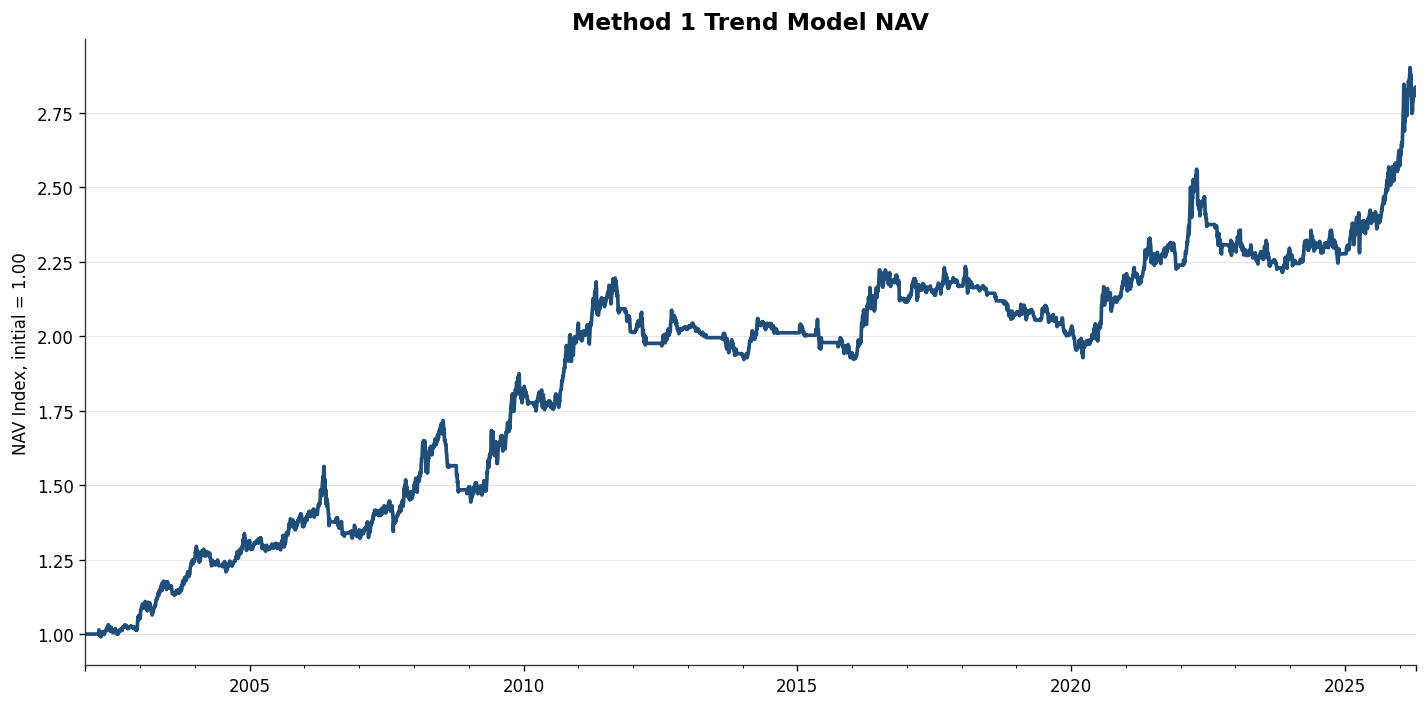

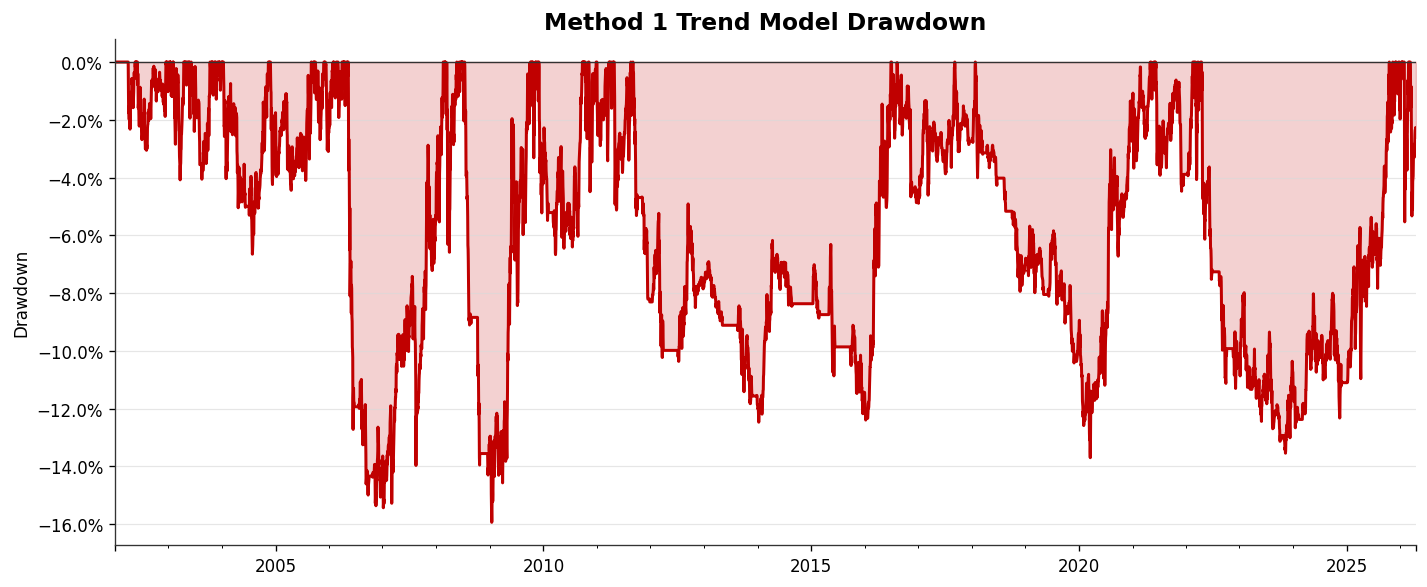

In [9]:

fig, ax = plt.subplots(figsize=(12, 6))
(nav / INITIAL_AUM).plot(ax=ax, color=COLORS["NAV"], linewidth=2.2)
ax.set_title("Method 1 Trend Model NAV")
ax.set_ylabel("NAV Index, initial = 1.00")
ax.set_xlabel("")
clean_axis(ax)
savefig("method1_nav_index.png")

fig, ax = plt.subplots(figsize=(12, 5))
drawdown.plot(ax=ax, color=COLORS["Drawdown"], linewidth=1.8)
ax.axhline(0, color="#333333", linewidth=0.8)
ax.fill_between(drawdown.index, drawdown.values, 0, color=COLORS["Drawdown"], alpha=0.18)
ax.set_title("Method 1 Trend Model Drawdown")
ax.set_ylabel("Drawdown")
ax.set_xlabel("")
clean_axis(ax, percent_y=True)
savefig("method1_drawdown.png")


## Exposure, leverage, and active signals

/usr/lib/python3.13/copy.py:254: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  y = func(*args)


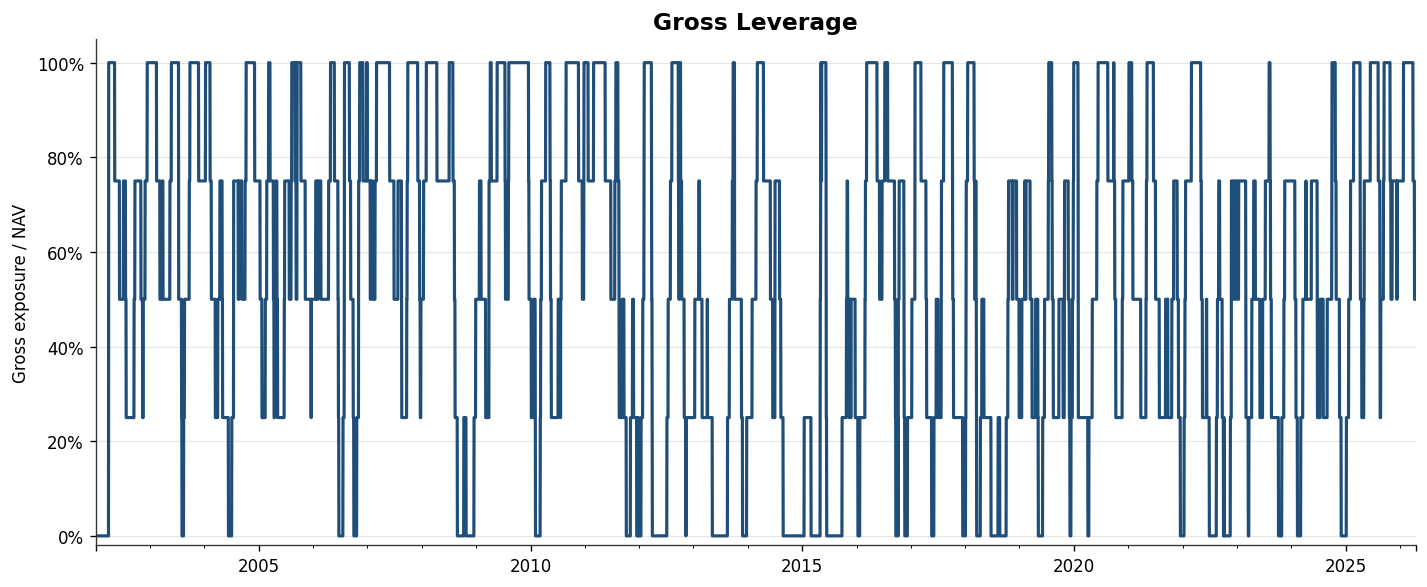

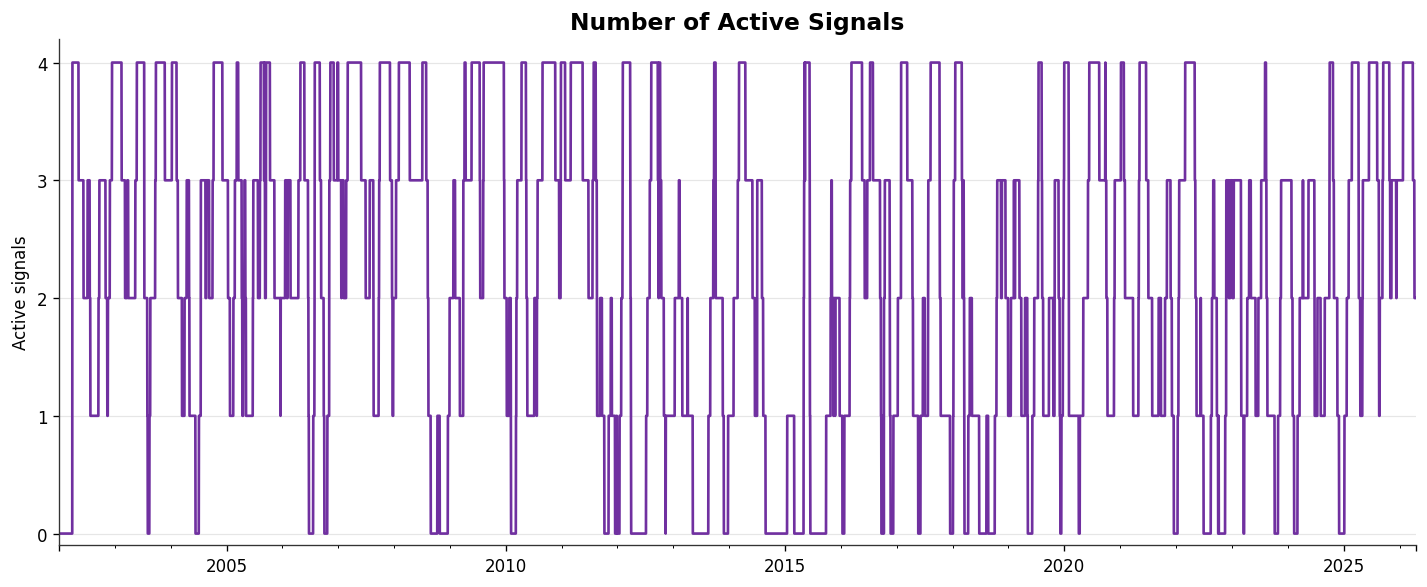

In [10]:

fig, ax = plt.subplots(figsize=(12, 5))
gross_leverage.plot(ax=ax, color=COLORS["NAV"], linewidth=1.9)
ax.set_title("Gross Leverage")
ax.set_ylabel("Gross exposure / NAV")
ax.set_xlabel("")
ax.set_ylim(-0.02, 1.05)
clean_axis(ax, percent_y=True)
savefig("method1_gross_leverage.png")

fig, ax = plt.subplots(figsize=(12, 5))
active_signals.plot(ax=ax, color="#7030A0", linewidth=1.6)
ax.set_title("Number of Active Signals")
ax.set_ylabel("Active signals")
ax.set_xlabel("")
ax.set_ylim(-0.1, 4.2)
ax.set_yticks([0, 1, 2, 3, 4])
clean_axis(ax)
savefig("method1_active_signals.png")


## Monthly returns

In [11]:

monthly_ret = (1.0 + strategy_ret).resample("ME").prod() - 1.0
monthly_table = monthly_ret.to_frame("return")
monthly_table["year"] = monthly_table.index.year
monthly_table["month"] = monthly_table.index.strftime("%b")

monthly_pivot = monthly_table.pivot(index="year", columns="month", values="return")
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_pivot = monthly_pivot.reindex(columns=month_order)

annual_ret = (1.0 + monthly_ret).groupby(monthly_ret.index.year).prod() - 1.0
monthly_pivot["Annual"] = annual_ret

def color_returns(val):
    if pd.isna(val):
        return ""
    if val > 0.06:
        return "background-color: #D9EAD3; color: #174A1A"
    if val < -0.02:
        return "background-color: #F4CCCC; color: #7F0000"
    return ""

monthly_display = monthly_pivot.style.format("{:.1%}").map(color_returns)
monthly_display


month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
year,,,,,,,,,,,,,
2002,0.0%,0.0%,0.0%,0.8%,1.8%,-1.6%,-0.5%,1.0%,1.2%,-0.1%,-1.0%,3.5%,5.2%
2003,4.8%,-0.5%,-1.4%,5.1%,1.7%,0.3%,-1.0%,-0.2%,0.7%,3.1%,1.3%,4.0%,19.0%
2004,-0.3%,2.6%,-0.4%,-3.0%,0.3%,-0.8%,-0.9%,1.8%,1.1%,2.1%,3.4%,-0.8%,4.9%
2005,-0.6%,1.1%,-1.6%,-0.8%,0.7%,-0.5%,0.5%,2.0%,4.7%,-2.2%,2.3%,-0.9%,4.4%
2006,2.8%,0.2%,0.7%,4.9%,-3.5%,-4.5%,0.3%,-0.8%,-2.4%,0.2%,1.9%,-1.6%,-2.1%
2007,0.1%,1.1%,1.7%,1.9%,0.4%,0.1%,1.0%,-3.4%,3.2%,5.2%,-3.0%,1.7%,9.9%
2008,3.4%,6.8%,-4.3%,3.0%,2.4%,3.1%,-3.6%,-4.4%,0.0%,-5.2%,0.0%,0.6%,1.0%
2009,-0.7%,0.3%,-0.7%,2.2%,9.2%,-1.0%,1.2%,-1.0%,4.9%,2.7%,4.6%,-2.6%,20.3%
2010,-1.4%,0.3%,-0.2%,2.5%,-2.7%,0.6%,0.8%,-0.6%,6.5%,2.6%,-0.1%,5.1%,13.8%


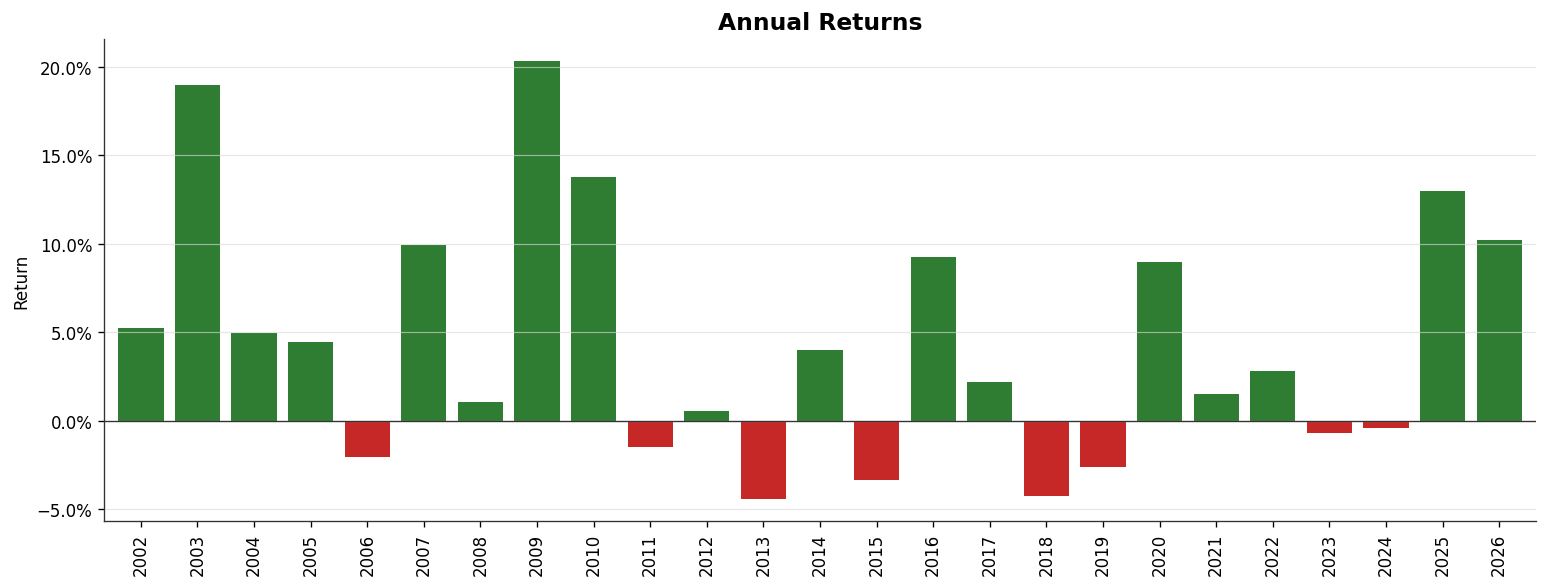

In [12]:

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = [COLORS["Positive"] if x >= 0 else COLORS["Negative"] for x in annual_ret]
annual_ret.plot(kind="bar", ax=ax, color=bar_colors, width=0.8)
ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_title("Annual Returns")
ax.set_ylabel("Return")
ax.set_xlabel("")
clean_axis(ax, percent_y=True)
savefig("method1_annual_returns.png")


## Dollar holdings and cash allocation

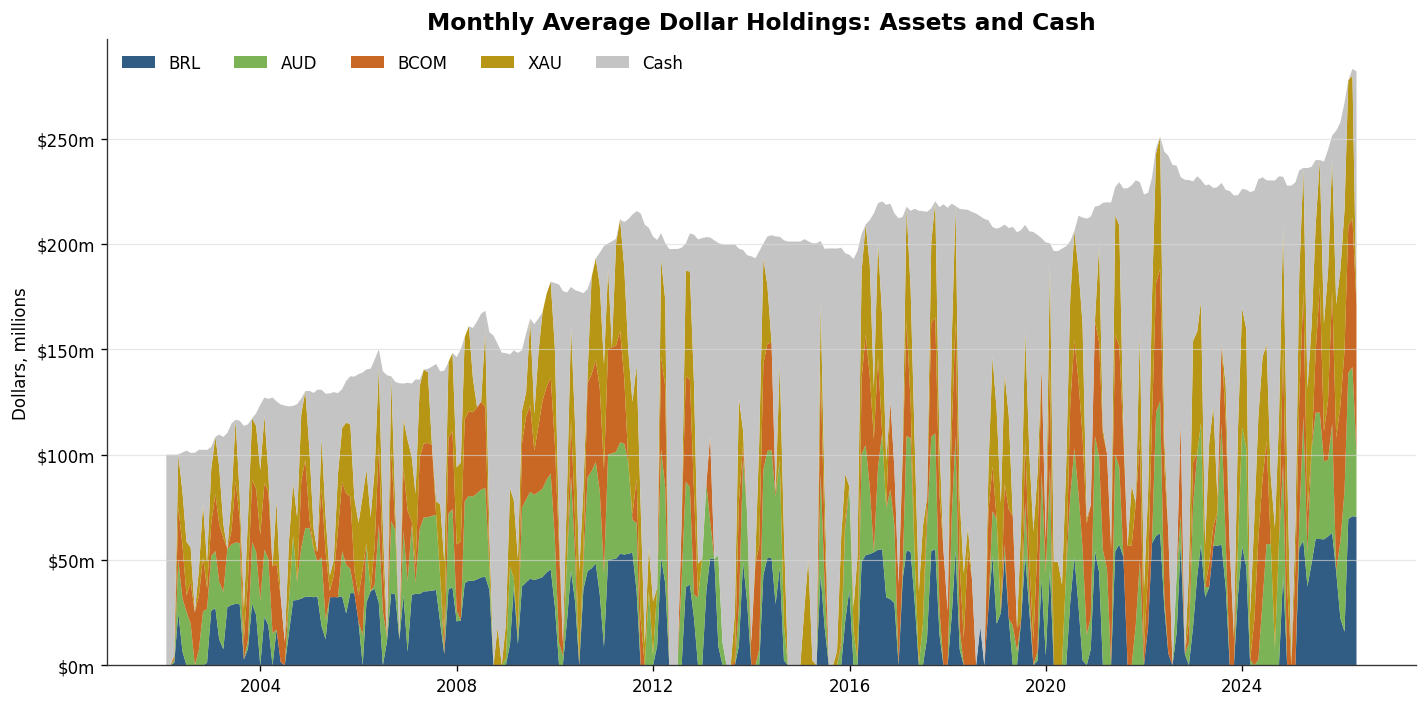

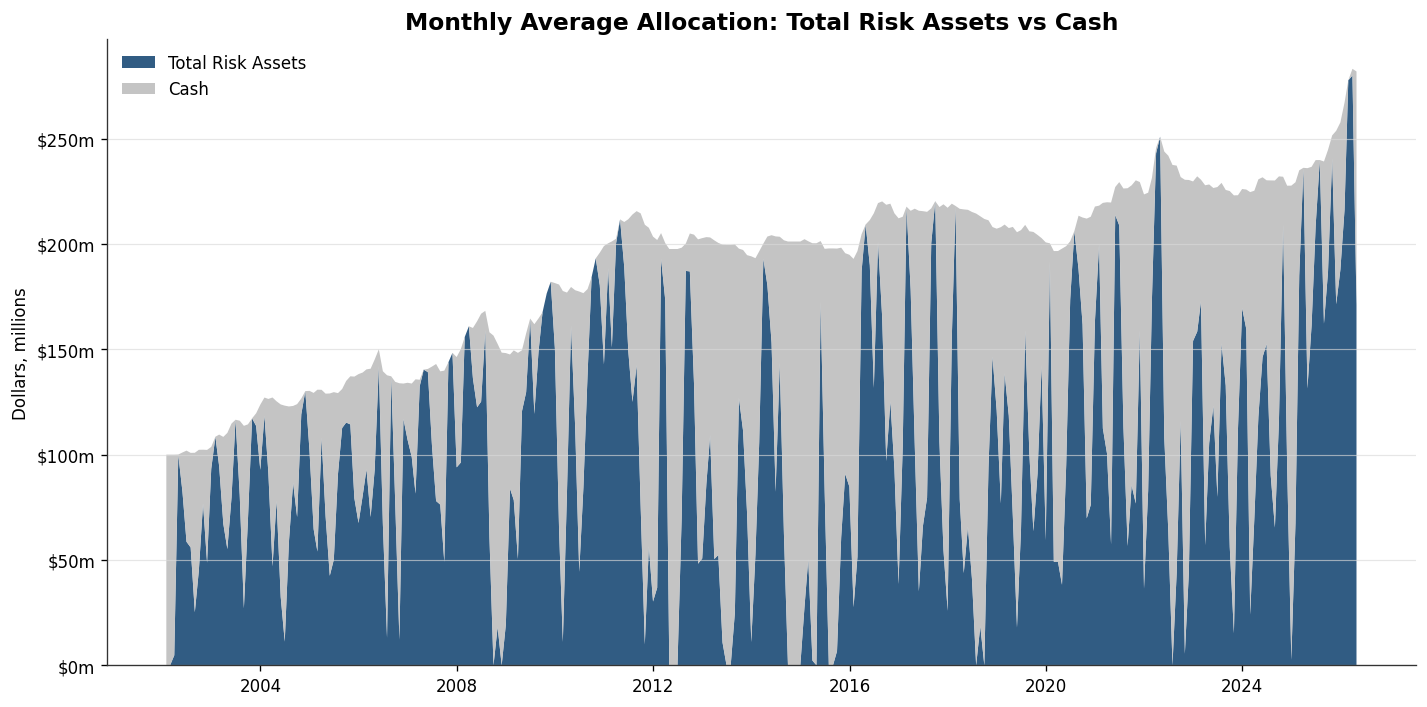

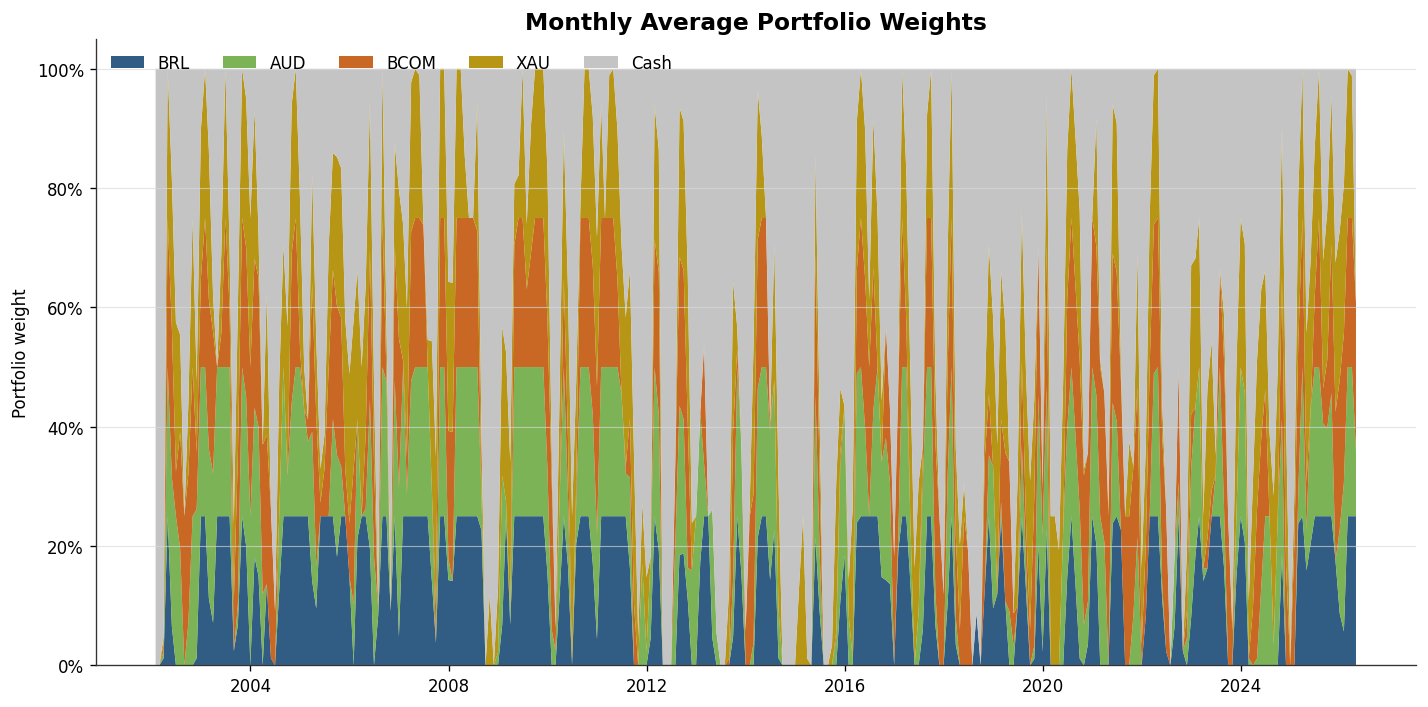

In [13]:

holdings_monthly = holdings.resample("ME").mean()
holdings_monthly_m = holdings_monthly / 1_000_000

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(
    holdings_monthly_m.index,
    holdings_monthly_m["BRL"],
    holdings_monthly_m["AUD"],
    holdings_monthly_m["BCOM"],
    holdings_monthly_m["XAU"],
    holdings_monthly_m["Cash"],
    labels=["BRL", "AUD", "BCOM", "XAU", "Cash"],
    colors=[COLORS[a] for a in ["BRL", "AUD", "BCOM", "XAU", "Cash"]],
    alpha=0.92,
)
ax.set_title("Monthly Average Dollar Holdings: Assets and Cash")
ax.set_ylabel("Dollars, millions")
ax.set_xlabel("")
ax.legend(loc="upper left", ncol=5)
clean_axis(ax, millions_y=True)
savefig("method1_monthly_assets_and_cash_holdings.png")

assets_total_monthly_m = holdings_monthly[asset_order].sum(axis=1) / 1_000_000
cash_monthly_m = holdings_monthly["Cash"] / 1_000_000

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(
    holdings_monthly.index,
    assets_total_monthly_m,
    cash_monthly_m,
    labels=["Total Risk Assets", "Cash"],
    colors=[COLORS["Risk Assets"], COLORS["Cash"]],
    alpha=0.92,
)
ax.set_title("Monthly Average Allocation: Total Risk Assets vs Cash")
ax.set_ylabel("Dollars, millions")
ax.set_xlabel("")
ax.legend(loc="upper left")
clean_axis(ax, millions_y=True)
savefig("method1_monthly_total_assets_vs_cash.png")

weights_with_cash = weights.copy()
weights_with_cash["Cash"] = 1.0 - weights.sum(axis=1)
weights_monthly = weights_with_cash.resample("ME").mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(
    weights_monthly.index,
    weights_monthly["BRL"],
    weights_monthly["AUD"],
    weights_monthly["BCOM"],
    weights_monthly["XAU"],
    weights_monthly["Cash"],
    labels=["BRL", "AUD", "BCOM", "XAU", "Cash"],
    colors=[COLORS[a] for a in ["BRL", "AUD", "BCOM", "XAU", "Cash"]],
    alpha=0.92,
)
ax.set_title("Monthly Average Portfolio Weights")
ax.set_ylabel("Portfolio weight")
ax.set_xlabel("")
ax.legend(loc="upper left", ncol=5)
clean_axis(ax, percent_y=True)
savefig("method1_monthly_average_weights.png")


## Trade return histograms

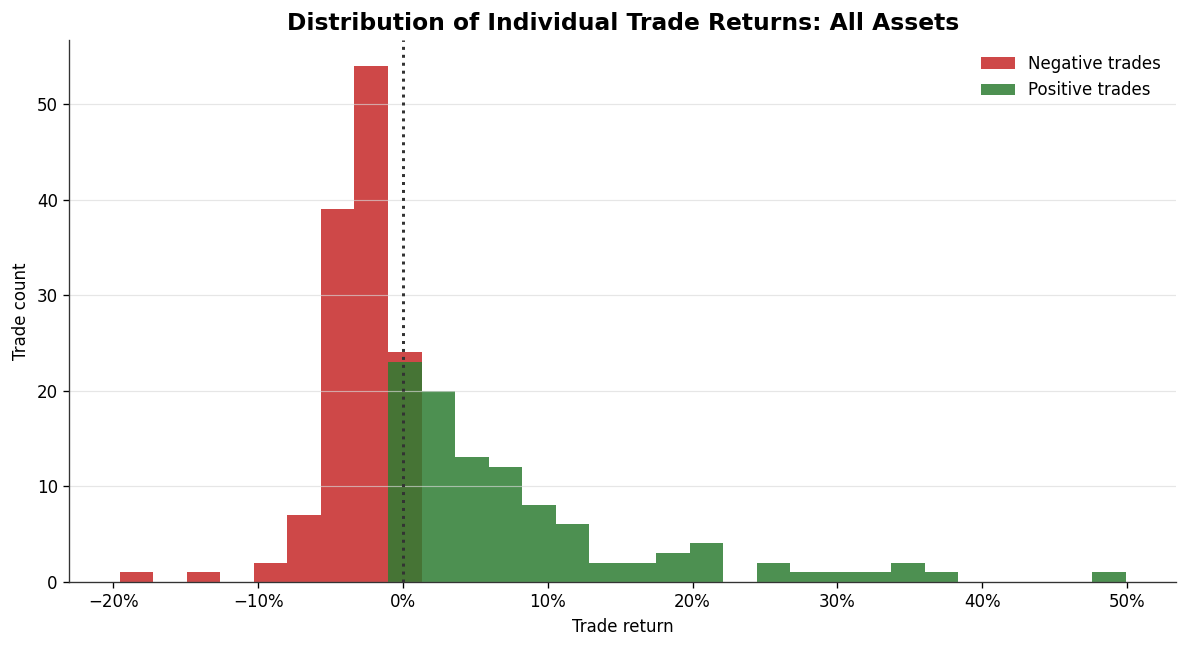

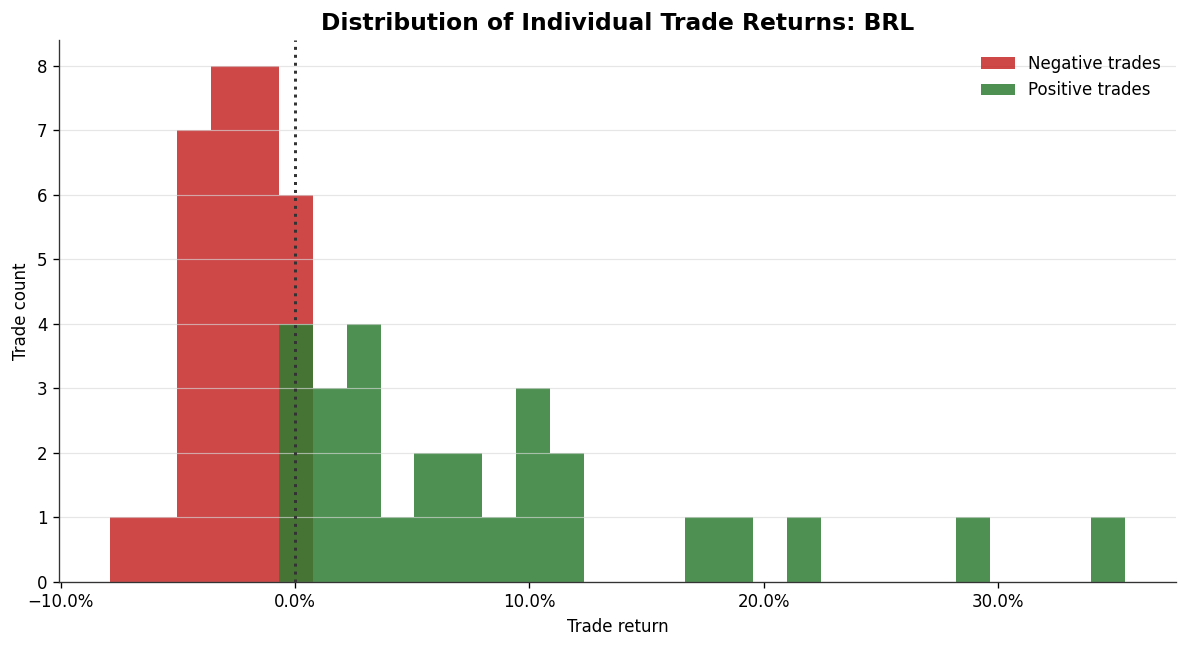

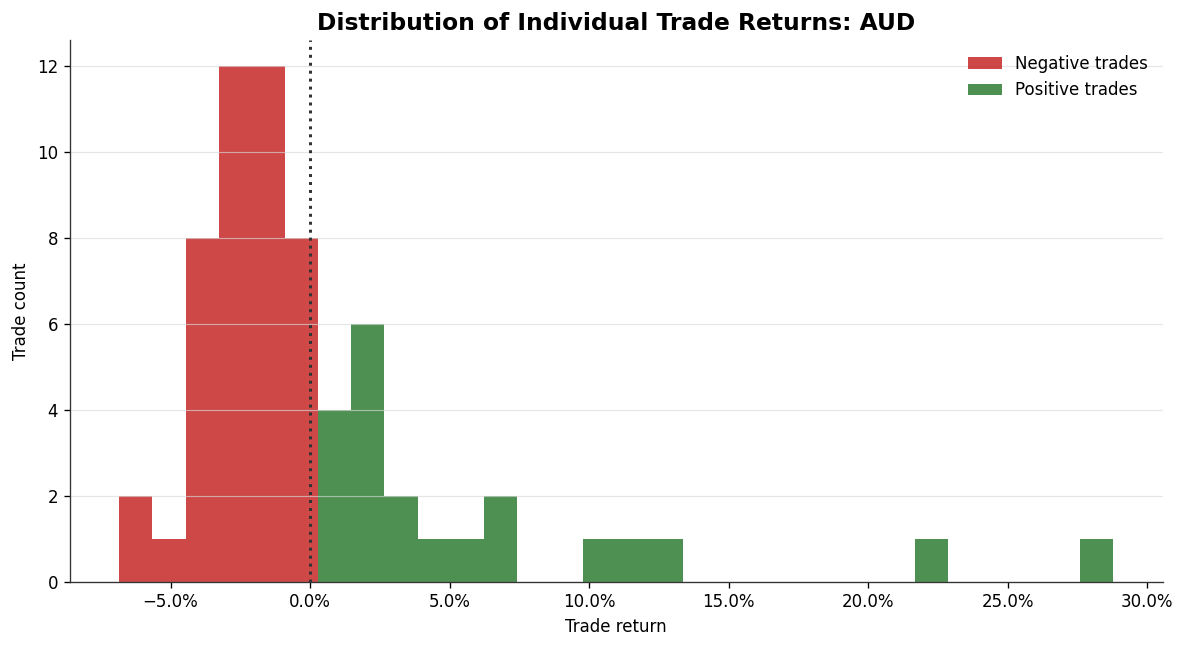

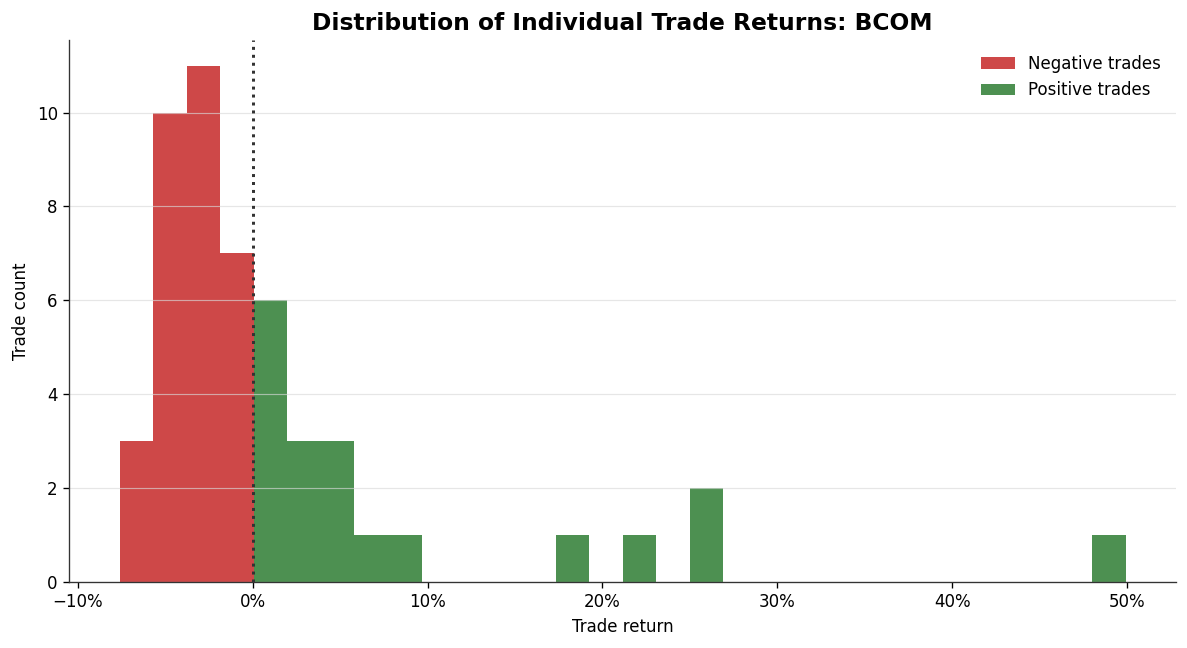

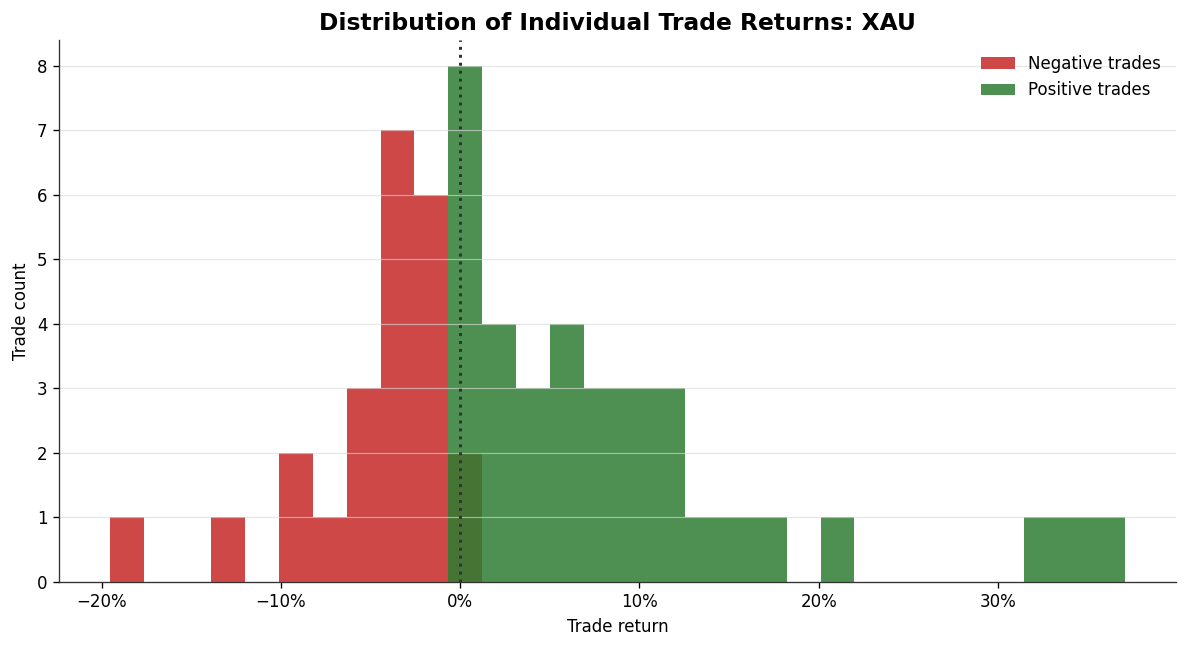

In [14]:

def plot_trade_hist(data, title, filename, bins=30):
    x = data.dropna().astype(float)
    if len(x) == 0:
        return

    lo = min(x.min(), -0.01)
    hi = max(x.max(), 0.01)
    edges = np.linspace(lo, hi, bins + 1)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.hist(x[x < 0], bins=edges, color=COLORS["Negative"], alpha=0.85, label="Negative trades")
    ax.hist(x[x >= 0], bins=edges, color=COLORS["Positive"], alpha=0.85, label="Positive trades")
    ax.axvline(0, color="#333333", linestyle=":", linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel("Trade return")
    ax.set_ylabel("Trade count")
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(loc="upper right")
    clean_axis(ax)
    savefig(filename)

plot_trade_hist(
    trades["trade_return_unweighted"],
    "Distribution of Individual Trade Returns: All Assets",
    "method1_trade_return_hist_all_assets.png",
)

for asset in asset_order:
    plot_trade_hist(
        trades.loc[trades["asset"] == asset, "trade_return_unweighted"],
        f"Distribution of Individual Trade Returns: {asset}",
        f"method1_trade_return_hist_{asset.lower()}.png",
    )


## Turnover charts

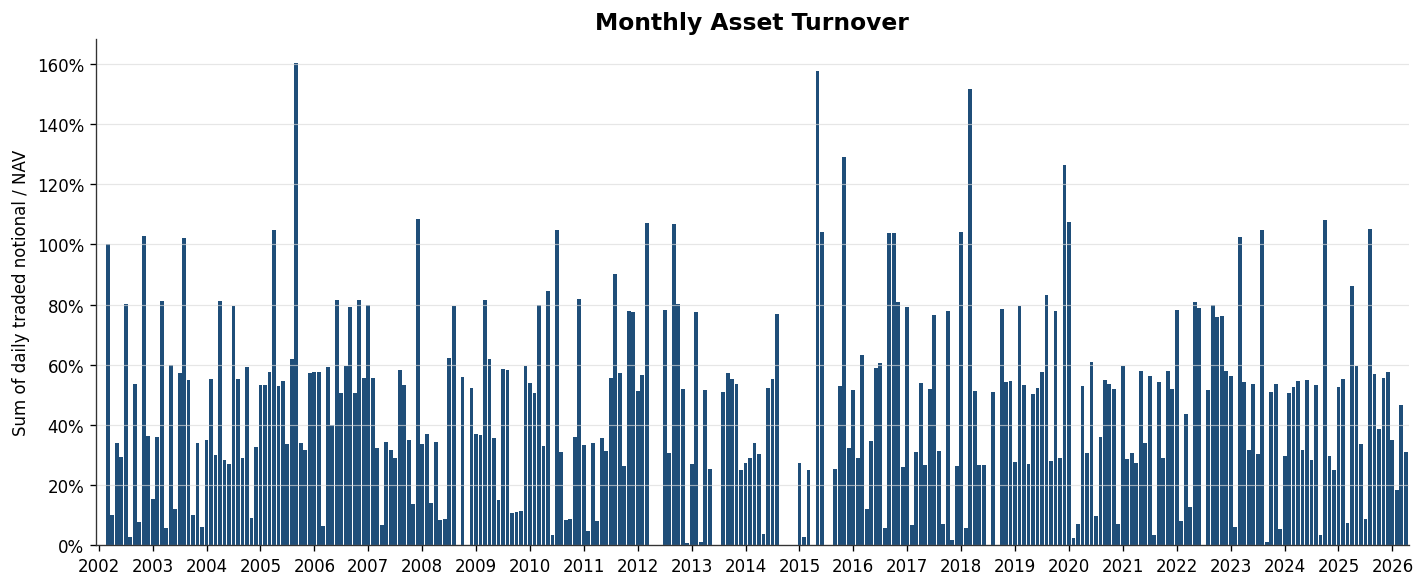

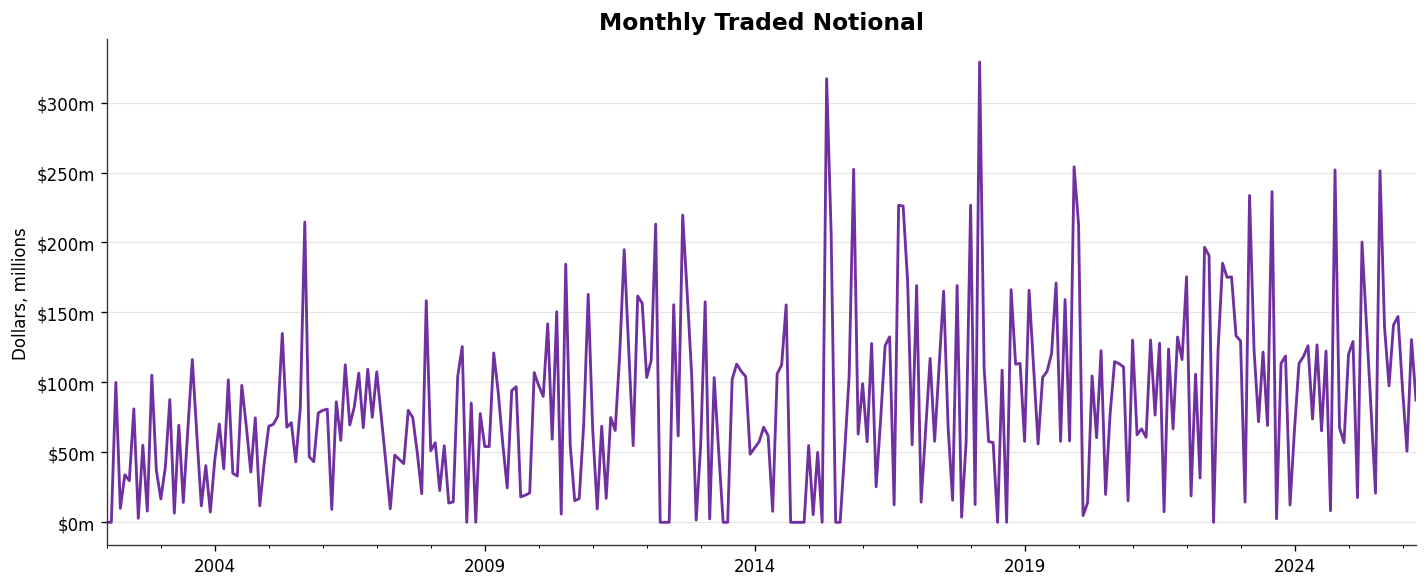

In [15]:

monthly_turnover = asset_turnover.resample("ME").sum()
monthly_traded_dollars_m = traded_dollars.resample("ME").sum() / 1_000_000

fig, ax = plt.subplots(figsize=(12, 5))
monthly_turnover.plot(kind="bar", ax=ax, color=COLORS["NAV"], width=0.85)
ax.set_title("Monthly Asset Turnover")
ax.set_ylabel("Sum of daily traded notional / NAV")
ax.set_xlabel("")
ax.set_xticks(np.arange(0, len(monthly_turnover), 12))
ax.set_xticklabels([d.strftime("%Y") for d in monthly_turnover.index[::12]], rotation=0)
clean_axis(ax, percent_y=True)
savefig("method1_monthly_turnover.png")

fig, ax = plt.subplots(figsize=(12, 5))
monthly_traded_dollars_m.plot(ax=ax, color="#7030A0", linewidth=1.7)
ax.set_title("Monthly Traded Notional")
ax.set_ylabel("Dollars, millions")
ax.set_xlabel("")
clean_axis(ax, millions_y=True)
savefig("method1_monthly_traded_notional.png")


## Asset-level trade summary

In [16]:

trade_summary_display = trade_summary_by_asset.copy()

pct_cols = [
    "avg_trade_return_unweighted",
    "median_trade_return_unweighted",
    "best_trade",
    "worst_trade",
    "win_rate",
]
for col in pct_cols:
    trade_summary_display[col] = trade_summary_display[col].map(lambda x: f"{x:.2%}")

for col in ["avg_holding_days", "median_holding_days"]:
    trade_summary_display[col] = trade_summary_display[col].map(lambda x: f"{x:.1f}")

trade_summary_display


,trade_count,wins,losses,avg_holding_days,median_holding_days,avg_trade_return_unweighted,median_trade_return_unweighted,best_trade,worst_trade,win_rate
asset,,,,,,,,,,
BRL,58,27,31,56.5,44.0,2.55%,-0.07%,35.44%,-7.91%,46.55%
AUD,64,21,43,52.3,41.5,0.47%,-1.34%,28.78%,-6.84%,32.81%
BCOM,50,19,31,68.3,49.0,1.64%,-1.52%,49.91%,-7.60%,38.00%
XAU,58,35,23,65.4,52.0,3.51%,1.06%,37.10%,-19.55%,60.34%


## Recent trades

In [17]:

recent_trades = trades.sort_values("entry_date").tail(20).copy()
recent_trades["trade_return_unweighted"] = recent_trades["trade_return_unweighted"].map(lambda x: f"{x:.2%}")
recent_trades


,asset,entry_date,exit_date,holding_days,trade_return_unweighted,win
167,BCOM,2024-03-20,2024-06-26,70,1.83%,True
115,AUD,2024-04-10,2024-04-11,1,-1.49%,False
116,AUD,2024-05-16,2024-08-05,57,-2.39%,False
227,XAU,2024-07-15,2024-12-03,101,9.44%,True
117,AUD,2024-08-30,2024-10-30,43,-3.60%,False
53,BRL,2024-10-01,2024-10-24,17,-4.71%,False
168,BCOM,2024-10-02,2024-11-21,36,-2.75%,False
169,BCOM,2025-01-07,2025-04-10,67,0.44%,True
228,XAU,2025-01-22,2025-08-21,151,21.99%,True
54,BRL,2025-02-04,2025-04-21,54,0.77%,True


## Save outputs

In [18]:

daily_output = pd.concat(
    {
        "asset_returns": asset_returns,
        "signals": signals,
        "positions": positions,
        "weights": weights,
        "results": results,
        "holdings": holdings,
        "turnover": turnover_daily,
    },
    axis=1,
)

daily_output.to_csv(OUTPUT_DIR / "method1_daily_backtest.csv")
daily_portfolio.to_csv(OUTPUT_DIR / "method1_daily_portfolio_holdings.csv")
monthly_pivot.to_csv(OUTPUT_DIR / "method1_monthly_returns.csv")
summary.to_csv(OUTPUT_DIR / "method1_summary.csv", index=False)
turnover_daily.to_csv(OUTPUT_DIR / "method1_turnover_daily.csv")
turnover_summary.to_csv(OUTPUT_DIR / "method1_turnover_summary.csv", index=False)
trade_summary_by_asset.to_csv(OUTPUT_DIR / "method1_trade_summary_by_asset.csv")
trades.to_csv(OUTPUT_DIR / "method1_trades.csv", index=False)

sorted([p.name for p in OUTPUT_DIR.glob("method1_*")])


['method1_active_signals.png',
 'method1_annual_returns.png',
 'method1_daily_backtest.csv',
 'method1_daily_portfolio_holdings.csv',
 'method1_drawdown.png',
 'method1_gross_leverage.png',
 'method1_monthly_assets_and_cash_holdings.png',
 'method1_monthly_average_weights.png',
 'method1_monthly_returns.csv',
 'method1_monthly_total_assets_vs_cash.png',
 'method1_monthly_traded_notional.png',
 'method1_monthly_turnover.png',
 'method1_nav_index.png',
 'method1_summary.csv',
 'method1_trade_return_hist_all_assets.png',
 'method1_trade_return_hist_aud.png',
 'method1_trade_return_hist_bcom.png',
 'method1_trade_return_hist_brl.png',
 'method1_trade_return_hist_xau.png',
 'method1_trade_summary_by_asset.csv',
 'method1_trades.csv',
 'method1_turnover_daily.csv',
 'method1_turnover_summary.csv']